### Correlations analysis

In [24]:
# Packages
from pandas import read_csv
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from numpy import arange
import matplotlib.pyplot as plt

from sklearnex import patch_sklearn
patch_sklearn()

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [17]:
# Read dataset
df = read_csv('../data/final_datasets/transformed_datasets/transformed_training_data.csv')
X = df.drop(columns = ['UHI Index'])
y = df['UHI Index']

In [18]:
# Correlations
corr = df.corr(method = 'spearman')

columns_correlations = []

for column, correlation in zip(df.columns[:-1], corr['UHI Index'].values[:-1]):
    columns_correlations.append([column, correlation])
    
sorted_list = sorted(columns_correlations, key = lambda x: abs(x[1]), reverse = False)

In [19]:
sorted_list

[['B8A_median_res250', 0.08461085864888286],
 ['B8_median_res250', 0.09201720677329445],
 ['datt1_median_res10', -0.10108123020924105],
 ['B11_median_res10', 0.10195918314314867],
 ['B6_median_res100', 0.10596795827905821],
 ['B7_median_res10', -0.10985123255260303],
 ['evi_median_res250', -0.11001918994187013],
 ['evi_median_res500', -0.11274960565233137],
 ['B7_median_res250', 0.11520517974160137],
 ['air_temperature_at_surface [degC]', 0.12055317981848745],
 ['B8A_median_res10', -0.12267888198808166],
 ['gndvi_median_res500', -0.12387542142333542],
 ['B8_median_res10', -0.1322424711376458],
 ['w_median_res10', -0.13322188268910745],
 ['si_median_res10', 0.14768125141276878],
 ['population_density_500', -0.15098557857928666],
 ['population_density_250', -0.15160137361686563],
 ['si_median_res250', 0.1567314794410387],
 ['B8A_median_res500', 0.15713042464356716],
 ['B5_median_res10', 0.16861792634929842],
 ['B3_median_res10', 0.1707866849907093],
 ['B8_median_res500', 0.17151369622742

In [23]:
# Columns of the full dataset
columns = X.columns.values.tolist()

# Empty lists to store R^2 values
train_values = []
test_values = []

### Iterate over different colums to test which set of dropped features gets the greatest test R^2
for i, row in enumerate(sorted_list[:-1]):
    columns.remove(row[0])
    X_tmp = X[columns]

    # Split in training and test data
    X_train_tmp, X_test_tmp, y_train_tmp, y_test_tmp = train_test_split(X_tmp, y, random_state=0)
    
    # Train the KNN Regressor model on the training data
    model_tmp = KNeighborsRegressor(algorithm = 'auto', 
                                    leaf_size = 30, 
                                    metric = 'manhattan', 
                                    metric_params = None, 
                                    n_jobs = 1, 
                                    n_neighbors = 3, 
                                    p = 2, 
                                    weights = 'distance')
    
    # Fit the model
    model_tmp.fit(X_train_tmp, y_train_tmp)
    
    # Make predictions on the training data
    train_predictions_tmp = model_tmp.predict(X_train_tmp)
    
    # Make predictions on the test data
    test_predictions_tmp = model_tmp.predict(X_test_tmp)
    
    # Calculate R-squared score for in-sample and test predictions
    train_r_squared = r2_score(y_train_tmp.tolist(), train_predictions_tmp)
    test_r_squared = r2_score(y_test_tmp.tolist(), test_predictions_tmp)
    
    # Append values
    train_values.append(train_r_squared)
    test_values.append(test_r_squared)
    
    print("Number of columns to drop {}. R^2 generated after dropping variables: Training {} | Test {}.".format(i + 1, train_r_squared, test_r_squared))

Number of columns to drop 1. R^2 generated after dropping variables: Training 1.0 | Test 0.9643581771314994.
Number of columns to drop 2. R^2 generated after dropping variables: Training 1.0 | Test 0.9640549716808995.
Number of columns to drop 3. R^2 generated after dropping variables: Training 1.0 | Test 0.9645208545739237.
Number of columns to drop 4. R^2 generated after dropping variables: Training 1.0 | Test 0.9650495505471713.
Number of columns to drop 5. R^2 generated after dropping variables: Training 1.0 | Test 0.9650079024471976.
Number of columns to drop 6. R^2 generated after dropping variables: Training 1.0 | Test 0.9649350072132769.
Number of columns to drop 7. R^2 generated after dropping variables: Training 1.0 | Test 0.9656358978946538.
Number of columns to drop 8. R^2 generated after dropping variables: Training 1.0 | Test 0.9650108123712863.
Number of columns to drop 9. R^2 generated after dropping variables: Training 1.0 | Test 0.9646139846041876.
Number of columns t

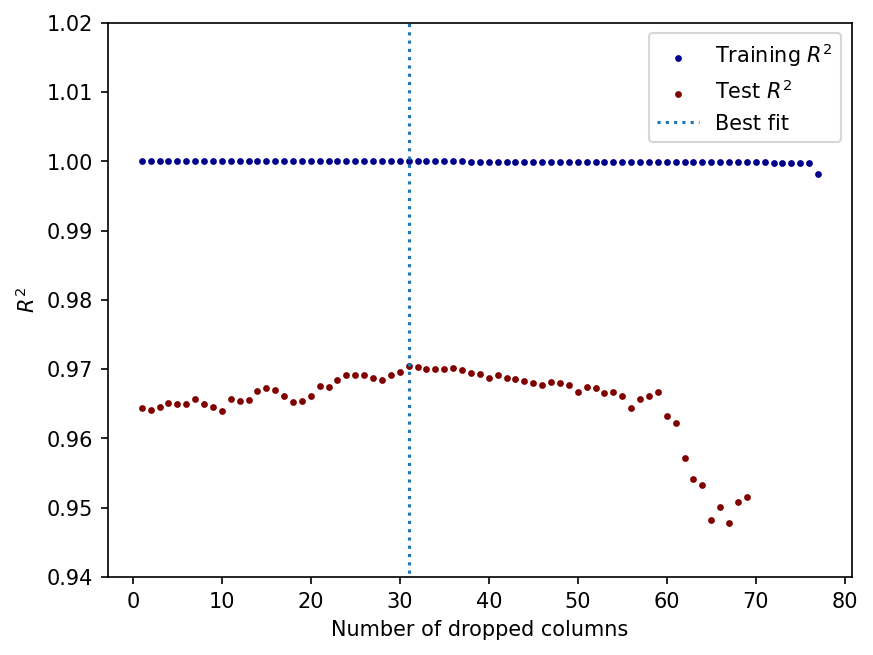

In [30]:
# Number of columns
number_of_dropped_columns = arange(1, len(df.columns[:-1]))

# Plot
fig, ax = plt.subplots(1, 1, dpi = 150)
ax.scatter(number_of_dropped_columns, train_values, s = 5.0, color = 'darkblue', label = 'Training $R^{2}$')
ax.scatter(number_of_dropped_columns, test_values, s = 5.0, color = 'maroon', label = 'Test $R^{2}$')
ax.vlines(31, ymax = 1.02, ymin = 0.0, ls = ':', label = 'Best fit')
#ax.invert_xaxis()
ax.set_xlabel('Number of dropped columns')
ax.set_ylabel('$R^{2}$')
ax.set_ylim(0.94, 1.02)
ax.legend()
plt.show()

In [31]:
for row in sorted_list[:31]:
    print(row[0])

B8A_median_res250
B8_median_res250
datt1_median_res10
B11_median_res10
B6_median_res100
B7_median_res10
evi_median_res250
evi_median_res500
B7_median_res250
air_temperature_at_surface [degC]
B8A_median_res10
gndvi_median_res500
B8_median_res10
w_median_res10
si_median_res10
population_density_500
population_density_250
si_median_res250
B8A_median_res500
B5_median_res10
B3_median_res10
B8_median_res500
B4_median_res10
B2_median_res10
evi_median_res100
B7_median_res500
B12_median_res10
units_density_250
ndmi_median_res10
si_median_res100
evi_median_res10
